# Environment Setup (Google Colab)

Uncomment and run the block below **only** when running on Google Colab. For local execution, skip this cell entirely.

In [1]:
# ── Run this block ONLY when using Google Colab ────────────────────────
# 1. Upload train_data.h5 and test_data.h5 to Google Drive at:  My Drive/ocular/
# 2. For images choose Option A (Drive) or Option B (Kaggle API)
# 3. Uncomment the entire block and run before any other cell

# import os, shutil
# from google.colab import drive
# drive.mount('/content/drive')

# DRIVE_DIR = '/content/drive/MyDrive/ocular'

# # Mirror the local directory structure so all relative paths work unchanged
# os.makedirs('/content/Main', exist_ok=True)
# os.makedirs('/content/models', exist_ok=True)
# os.makedirs('/content/notebooks', exist_ok=True)

# # Copy .h5 files into /content/Main/ (avoids Drive latency)
# shutil.copy(f'{DRIVE_DIR}/train_data.h5', '/content/Main/train_data.h5')
# shutil.copy(f'{DRIVE_DIR}/test_data.h5',  '/content/Main/test_data.h5')

# # Run notebook from /content/notebooks so ../Main/ and ../models/ resolve correctly
# os.chdir('/content/notebooks')

# # Option A — images already uploaded to Drive:
# IMAGE_FOLDER_PATH = f'{DRIVE_DIR}/preprocessed_images'

# # Option B — download from Kaggle (faster for large image sets):
# shutil.copy(f'{DRIVE_DIR}/kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
# os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
# os.system('kaggle datasets download -d andrewmvd/ocular-disease-recognition-odir5k -p /content/preprocessed_images --unzip')
# IMAGE_FOLDER_PATH = '/content/preprocessed_images'

# # Verify GPU is available (Runtime → Change runtime type → T4 GPU)
# import tensorflow as tf
# print('GPU:', tf.config.list_physical_devices('GPU'))


# 1. Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Recall, Precision

# 2. Data Loading

In [3]:
train_data_path = '../Main/train_data.h5'
test_data_path  = '../Main/test_data.h5'

train_data = pd.read_hdf(train_data_path)
test_data  = pd.read_hdf(test_data_path)
train_data.head()

,ID,Patient Age,Patient Sex,target,filename,diagnostic,binary_target
6306,4584,42,Male,1,4584_left.jpg,D,0
2244,3126,41,Male,0,3126_right.jpg,N,1
1716,2553,54,Female,0,2553_right.jpg,N,1
6368,4653,68,Male,1,4653_left.jpg,D,0
4970,2618,58,Male,0,2618_left.jpg,N,1


## 2.1 Feature / Target Split

In [4]:
X_train, y_train = train_data.drop(columns=['target']), train_data['target']
X_test, y_test = test_data.drop(columns=['target']), test_data['target']
print(y_train.value_counts())

target
0    2298
1    1286
7     566
3     234
2     227
4     213
6     186
5     103
Name: count, dtype: int64


## 2.2 Load Images

Images are resized to **224x224** — the native resolution for EfficientNetB0, maximising feature quality. This requires ~7-8 GB RAM for the full augmented training set; **Google Colab is recommended** for this configuration. EfficientNetB0 includes a built-in rescaling layer — images are passed as `float32 [0-255]` without manual normalisation.

In [5]:
# Use path set by Colab setup cell; fall back to local relative path
if "IMAGE_FOLDER_PATH" not in vars():
    IMAGE_FOLDER_PATH = '../preprocessed_images'
IMAGE_SIZE = (224, 224)  # EfficientNetB0 native resolution — requires ~7-8 GB RAM (Colab recommended)

def load_images(filenames):
    images = []
    for filename in filenames:
        img_path = os.path.join(IMAGE_FOLDER_PATH, filename)
        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.resize(img, IMAGE_SIZE)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype("float32")  # EfficientNetB0 has a built-in rescaling layer — no /255.0 needed
            images.append(img)
        else:
            print(f"Warning: La imagen {filename} no se pudo cargar.")
    return np.array(images)

X_train_images = load_images(X_train['filename'])


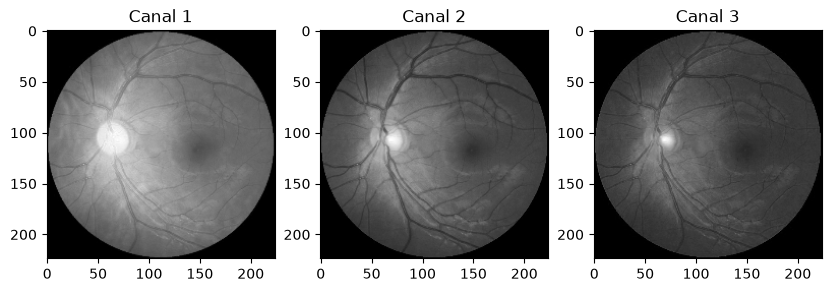

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].imshow(X_train_images[0][:,:,0], cmap="gray")
axs[0].set_title('Canal 1')
axs[1].imshow(X_train_images[0][:,:,1], cmap="gray")
axs[1].set_title('Canal 2')
axs[2].imshow(X_train_images[0][:,:,2], cmap="gray")
axs[2].set_title('Canal 3')
plt.show()

# 3. Model Architecture

**EfficientNetB0** (ImageNet pre-trained, frozen) with a trainable classification head:

```
GlobalAveragePooling2D -> Dense(256, ReLU, L2=0.01) -> Dropout(0.4) -> Dense(8, softmax)
```

The base is kept in inference mode (`training=False`) during Phase 4, preventing BatchNorm statistics from updating.

In [7]:
def build_transfer_model(input_shape=(224, 224, 3), num_classes=8):
    base_model = tf.keras.applications.EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # base congelada: solo se entrena la cabeza densa

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu',
                               kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs), base_model

input_shape = (224, 224, 3)
model, base_model = build_transfer_model(input_shape)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,563 (16.71 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Reset `y_train` index after loading from HDF5 to align with the image array.

In [8]:
y_train = y_train.reset_index(drop=True)
print(y_train.head())

0    1
1    0
2    0
3    1
4    0
Name: target, dtype: int64


# 4. Validation Split

Extract a stratified validation set (20% per class) from the **original** images **before** augmentation is applied. This prevents augmented copies of validation images from leaking into the training set.

In [9]:
np.random.seed(511)  # fixed seed for reproducibility
validation_indices = []
for cls in sorted(y_train.unique()):
    cls_indices = y_train[y_train == cls].index
    n_val = max(1, int(len(cls_indices) * 0.2))
    chosen = np.random.choice(cls_indices, n_val, replace=False)
    validation_indices.extend(chosen)

validation_indices = np.array(validation_indices)

X_val = X_train_images[validation_indices]
y_val = y_train[validation_indices]

X_train_images = np.delete(X_train_images, validation_indices, axis=0)
y_train = y_train.drop(validation_indices).reset_index(drop=True)

print(f"Validation set: {X_val.shape[0]}  |  Training set: {X_train_images.shape[0]}")
print("Clases en validación:", dict(pd.Series(y_val.values).value_counts().sort_index()))

# 5. Data Augmentation

A **tiered strategy** based on class size: the most underrepresented classes receive more
augmented copies. Ten geometrically and photometrically distinct transforms are available;
each class draws from the first N of them to avoid exact duplicates.

| Class | Original | Copies | Total | Transforms used |
|---|---|---|---|---|
| Normal (0) | 1839 | 0 | 1839 | — |
| Diabetic (1) | 1029 | 0 | 1029 | — |
| Glaucoma (2) | 182 | 7 | 1456 | flips + rotations |
| Cataract (3) | 188 | 7 | 1504 | flips + rotations |
| AMD (4) | 171 | 7 | 1368 | flips + rotations |
| Hypertension (5) | 83 | 9 | 830 | all 10 transforms |
| Myopia (6) | 149 | 7 | 1192 | flips + rotations |
| Other (7) | 453 | 1 | 906 | flip H |

**Resulting imbalance ratio: ~2.2:1** (down from 5.5:1 with the previous strategy).

In [10]:
def augment_images(images, labels):
    # 10 geometrically/photometrically distinct transforms — no exact duplicates
    def make_transforms(img):
        return [
            tf.image.flip_left_right(img),
            tf.image.flip_up_down(img),
            tf.image.flip_left_right(tf.image.flip_up_down(img)),
            tf.image.rot90(img, k=1),
            tf.image.rot90(img, k=2),
            tf.image.rot90(img, k=3),
            tf.image.random_brightness(img, max_delta=0.2),
            tf.image.random_contrast(img, lower=0.8, upper=1.2),
            tf.image.flip_left_right(tf.image.rot90(img, k=1)),
            tf.image.flip_left_right(tf.image.rot90(img, k=3)),
        ]

    # Copies per class — tiered by representation gap
    copies_per_class = {
        0: 0,   # Normal       — already dominant
        1: 0,   # Diabetic     — already well represented
        2: 7,   # Glaucoma
        3: 7,   # Cataract
        4: 7,   # AMD
        5: 9,   # Hypertension — most underrepresented
        6: 7,   # Myopia
        7: 1,   # Other        — reduce its dominance
    }

    augmented_images = []
    augmented_labels = []

    for img, label in zip(images, labels):
        n_copies = copies_per_class[label]
        if n_copies > 0:
            t = make_transforms(img)
            for i in range(n_copies):
                augmented_images.append(t[i])
                augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_labels)

In [11]:
X_train_augmented, y_train_augmented = augment_images(X_train_images, y_train)
print(f"Augmented: {X_train_augmented.shape[0]}  |  Training originals: {X_train_images.shape[0]}")

Augmented: 6030  |  Training originals: 4094


## 5.1 Augmented Sample Images

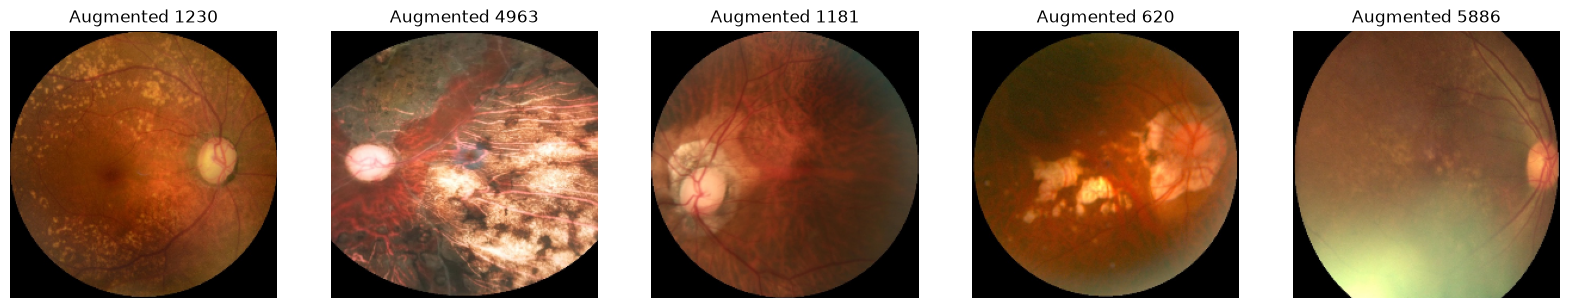

Augmented: 6030  |  Original: 4094


In [12]:
num_images_to_plot = 5
fig, axes = plt.subplots(1, num_images_to_plot, figsize=(20, 4))
for i in range(num_images_to_plot):
    idx = np.random.randint(0, len(X_train_augmented))
    axes[i].imshow(X_train_augmented[idx].astype(np.uint8))
    axes[i].set_title(f"Augmented {idx}")
    axes[i].axis("off")
plt.show()

print(f"Augmented: {X_train_augmented.shape[0]}  |  Original: {X_train_images.shape[0]}")

## 5.2 Combined Class Distribution

In [13]:
print("Class distribution in y_train:")
print(y_train.value_counts())

unique, counts = np.unique(y_train_augmented, return_counts=True)
print("\nClass distribution in y_train_augmented:")
print(dict(zip(unique, counts)))

Class distribution in y_train:
target
0    1839
1    1029
7     453
3     188
2     182
4     171
6     149
5      83
Name: count, dtype: int64

Class distribution in y_train_augmented:
{np.int64(2): np.int64(1274), np.int64(3): np.int64(1316), np.int64(4): np.int64(1197), np.int64(5): np.int64(747), np.int64(6): np.int64(1043), np.int64(7): np.int64(453)}


## 5.3 Combine Original and Augmented Data

In [14]:
X_train_combined = np.concatenate((X_train_images, X_train_augmented), axis=0)
y_train_combined = np.concatenate((y_train, y_train_augmented), axis=0)
# No se hace shuffle aqui - Keras lo hace internamente en model.fit (shuffle=True por defecto)
print(f"Total training samples: {X_train_combined.shape[0]}")

Total training samples: 10124


# 6. Training - Phase 4 (Frozen Base)

Train only the classification head. Class weights compensate for class imbalance. `ReduceLROnPlateau` halves the learning rate after 5 stagnant epochs; `EarlyStopping` (patience=25) restores the best checkpoint.

In [15]:
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_combined),
    y=y_train_combined
)
class_weights_dict = dict(enumerate(class_weights_array))
print("Class weights:", {k: round(v, 2) for k, v in class_weights_dict.items()})

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_combined,
    y_train_combined,
    epochs=120,
    validation_data=(X_val, y_val),
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights_dict
)

Class weights: {0: np.float64(0.69), 1: np.float64(1.23), 2: np.float64(0.87), 3: np.float64(0.84), 4: np.float64(0.93), 5: np.float64(1.52), 6: np.float64(1.06), 7: np.float64(1.4)}
Epoch 1/120
317/317 ━━━━━━━━━━━━━━━━━━━━ 287s 846ms/step - accuracy: 0.4830 - loss: 2.3262 - val_accuracy: 0.3503 - val_loss: 1.8173 - learning_rate: 0.0010
Epoch 2/120
317/317 ━━━━━━━━━━━━━━━━━━━━ 290s 915ms/step - accuracy: 0.5364 - loss: 1.4938 - val_accuracy: 0.3886 - val_loss: 1.6420 - learning_rate: 0.0010
Epoch 3/120
317/317 ━━━━━━━━━━━━━━━━━━━━ 296s 934ms/step - accuracy: 0.5393 - loss: 1.4341 - val_accuracy: 0.3621 - val_loss: 1.7819 - learning_rate: 0.0010
Epoch 4/120
317/317 ━━━━━━━━━━━━━━━━━━━━ 316s 914ms/step - accuracy: 0.5460 - loss: 1.4078 - val_accuracy: 0.5005 - val_loss: 1.4909 - learning_rate: 0.0010
Epoch 5/120
317/317 ━━━━━━━━━━━━━━━━━━━━ 328s 932ms/step - accuracy: 0.5467 - loss: 1.4017 - val_accuracy: 0.5113 - val_loss: 1.4965 - learning_rate: 0.0010
Epoch 6/120
317/317 ━━━━━━━━━━━━

# 7. Evaluation - Phase 4

Load test images and evaluate the frozen-base model on the held-out test set.

In [16]:
X_test_images = load_images(X_test['filename'])

## 7.1 Confusion Matrix

40/40 ━━━━━━━━━━━━━━━━━━━━ 43s 939ms/step


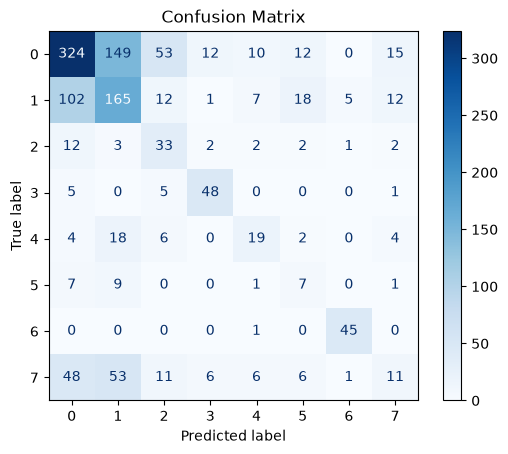

In [17]:
y_pred = model.predict(X_test_images)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

## 7.2 Loss & Accuracy

In [18]:
from sklearn.metrics import accuracy_score, log_loss

accuracy = accuracy_score(y_test, y_pred_classes)
loss = log_loss(y_test, y_pred)
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

Loss: 1.2518
Accuracy: 0.5098


## 7.3 Convolutional Activation Maps

Visualise the first four Conv2D feature maps from the EfficientNetB0 base to inspect what spatial patterns have been learned.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step


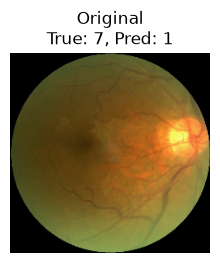

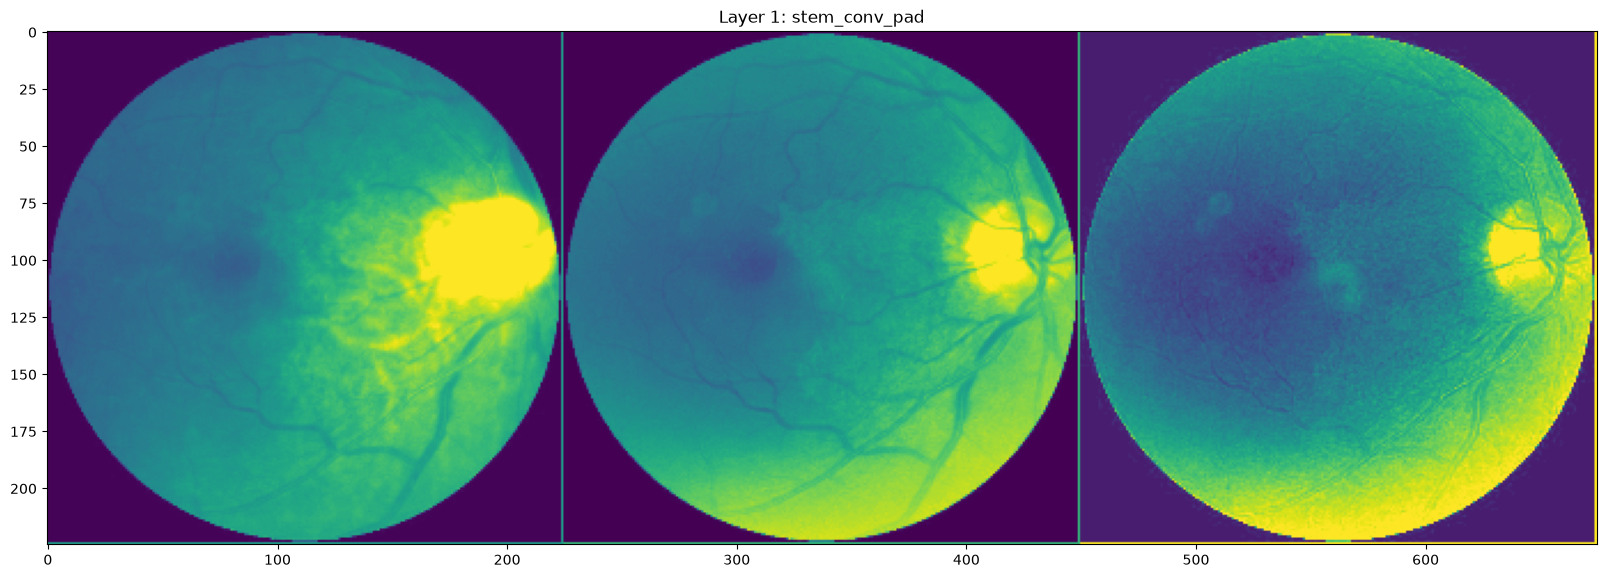

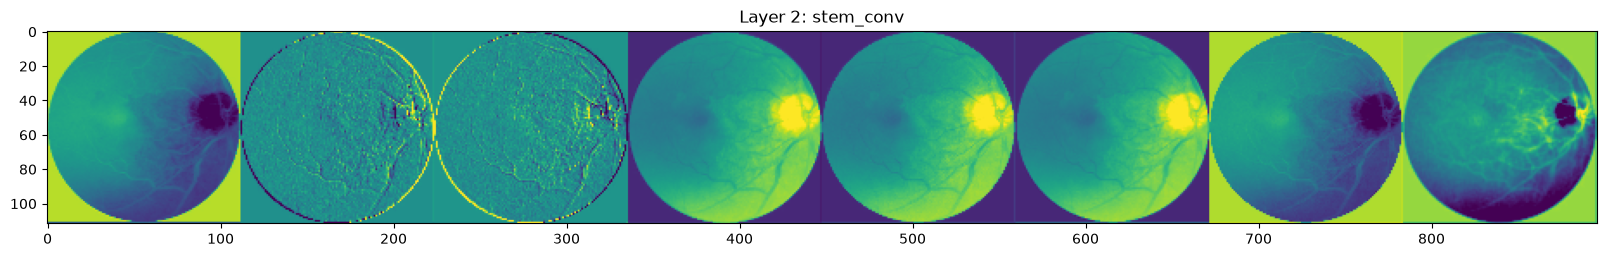

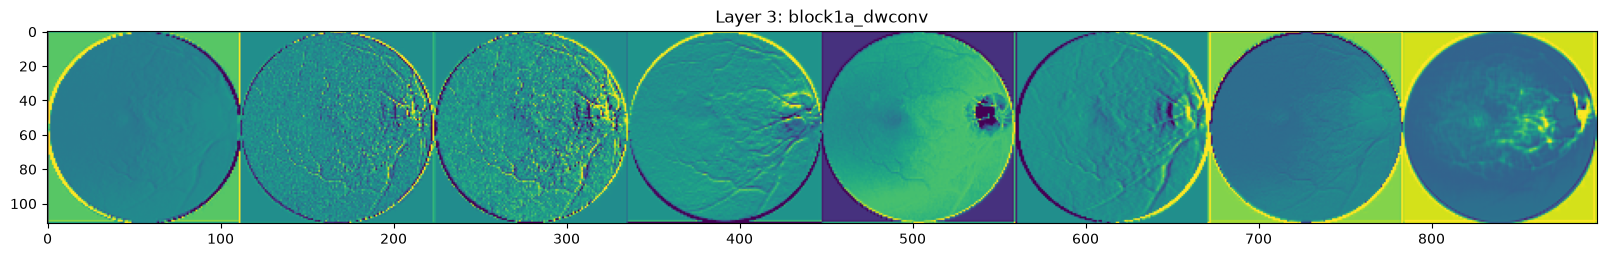

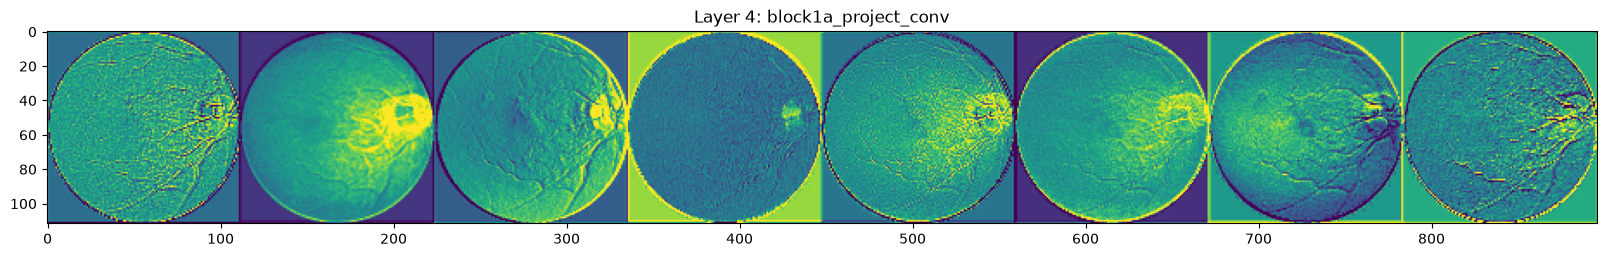

In [19]:
image_index = np.random.randint(0, len(X_test_images))
image = X_test_images[image_index]
true_class = y_test.iloc[image_index]
predicted_class = y_pred_classes[image_index]

# Con EfficientNetB0, las capas Conv2D están dentro del modelo base
conv_layers = [l for l in base_model.layers if 'conv' in l.name][:4]
layer_outputs = [l.output for l in conv_layers]
activation_model = tf.keras.models.Model(inputs=base_model.input, outputs=layer_outputs)
activations = activation_model.predict(np.expand_dims(image, axis=0))

plt.figure(figsize=(15, 5))
plt.subplot(1, len(activations) + 1, 1)
plt.imshow(image.astype(np.uint8))
plt.title(f"Original\nTrue: {true_class}, Pred: {predicted_class}")
plt.axis("off")

for i, activation in enumerate(activations):
    num_filters = min(activation.shape[-1], 8)
    size = activation.shape[1]
    display_grid = np.zeros((size, size * num_filters))
    for j in range(num_filters):
        x = activation[0, :, :, j]
        x -= x.mean()
        if x.std() != 0:
            x /= x.std()
        x *= 64
        x += 128
        x = np.clip(x, 0, 255).astype("uint8")
        display_grid[:, j * size:(j + 1) * size] = x
    scale = 20. / num_filters
    plt.figure(figsize=(scale * num_filters, scale))
    plt.title(f"Layer {i + 1}: {conv_layers[i].name}")
    plt.grid(False)
    plt.imshow(display_grid, aspect="auto", cmap="viridis")
plt.show()

## 7.4 Per-Class Classification Report

In [20]:
from sklearn.metrics import classification_report

classes = ['Normal', 'Diabetic Retinopathy', 'Glaucoma', 'Cataract',
           'Age-related Macular Degeneration', 'Hypertension', 'Myopia', 'Other']

report = classification_report(y_test, y_pred_classes, target_names=classes)
print(report)

                                  precision    recall  f1-score   support

                          Normal       0.65      0.56      0.60       575
            Diabetic Retinopathy       0.42      0.51      0.46       322
                        Glaucoma       0.28      0.58      0.37        57
                        Cataract       0.70      0.81      0.75        59
Age-related Macular Degeneration       0.41      0.36      0.38        53
                    Hypertension       0.15      0.28      0.19        25
                          Myopia       0.87      0.98      0.92        46
                           Other       0.24      0.08      0.12       142

                        accuracy                           0.51      1279
                       macro avg       0.46      0.52      0.47      1279
                    weighted avg       0.52      0.51      0.50      1279



In [21]:
model.save('../models/efficientnetb0_phase4.h5')
print('Phase 4 model saved -> models/efficientnetb0_phase4.h5')

Phase 4 model saved -> models/efficientnetb0_phase4.h5


# 8. Training - Phase 5 (Fine-tuning)

Unfreeze the **last 20 layers** of EfficientNetB0 and fine-tune with a very low learning rate (1e-5) to adapt the pre-trained features to the retinal domain.

> **Requires GPU.** Each epoch takes ~10-20 min on CPU. In Google Colab: *Runtime -> Change runtime type -> T4 GPU*.

In [22]:
# Phase 5: descongelar las últimas 20 capas de EfficientNetB0
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f"Capas entrenables: {sum(1 for l in base_model.layers if l.trainable)}/{len(base_model.layers)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tuning_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
fine_tuning_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7, min_lr=1e-8, verbose=1)

history_ft = model.fit(
    X_train_combined,
    y_train_combined,
    epochs=100,
    validation_data=(X_val, y_val),
    batch_size=16,
    callbacks=[fine_tuning_stopping, fine_tuning_lr],
    class_weight=class_weights_dict
)

## 8.1 Evaluation - Phase 5

40/40 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step 


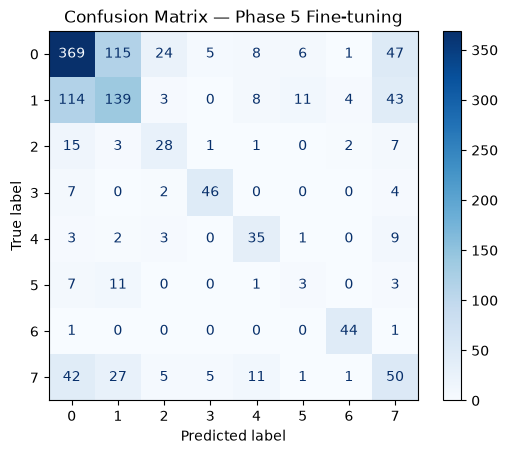

Loss:     1.1446
Accuracy: 0.5582

                                  precision    recall  f1-score   support

                          Normal       0.66      0.64      0.65       575
            Diabetic Retinopathy       0.47      0.43      0.45       322
                        Glaucoma       0.43      0.49      0.46        57
                        Cataract       0.81      0.78      0.79        59
Age-related Macular Degeneration       0.55      0.66      0.60        53
                    Hypertension       0.14      0.12      0.13        25
                          Myopia       0.85      0.96      0.90        46
                           Other       0.30      0.35      0.33       142

                        accuracy                           0.56      1279
                       macro avg       0.53      0.55      0.54      1279
                    weighted avg       0.56      0.56      0.56      1279



In [23]:
y_pred_ft = model.predict(X_test_images)
y_pred_ft_classes = np.argmax(y_pred_ft, axis=1)

cm_ft = confusion_matrix(y_test, y_pred_ft_classes)
disp_ft = ConfusionMatrixDisplay(confusion_matrix=cm_ft)
disp_ft.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix — Phase 5 Fine-tuning')
plt.show()

accuracy_ft = accuracy_score(y_test, y_pred_ft_classes)
loss_ft = log_loss(y_test, y_pred_ft)
print(f"Loss:     {loss_ft:.4f}")
print(f"Accuracy: {accuracy_ft:.4f}")

print()
print(classification_report(y_test, y_pred_ft_classes, target_names=classes))

In [24]:
model.save('../models/efficientnetb0_finetuned.keras')
print('Fine-tuned model saved -> models/efficientnetb0_finetuned.keras')

Fine-tuned model saved -> models/efficientnetb0_finetuned.keras
